In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix
)

In [5]:
data = pd.read_csv("ai4i2020.csv")

print(data.head())

print("\nColumns:")

print(data.columns)

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [6]:
print("\nDataset Shape:")

print(data.shape)

print("\nMissing Values:")

print(data.isnull().sum())

print("\nDataset Info:")

print(data.info())


Dataset Shape:
(10000, 14)

Missing Values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000

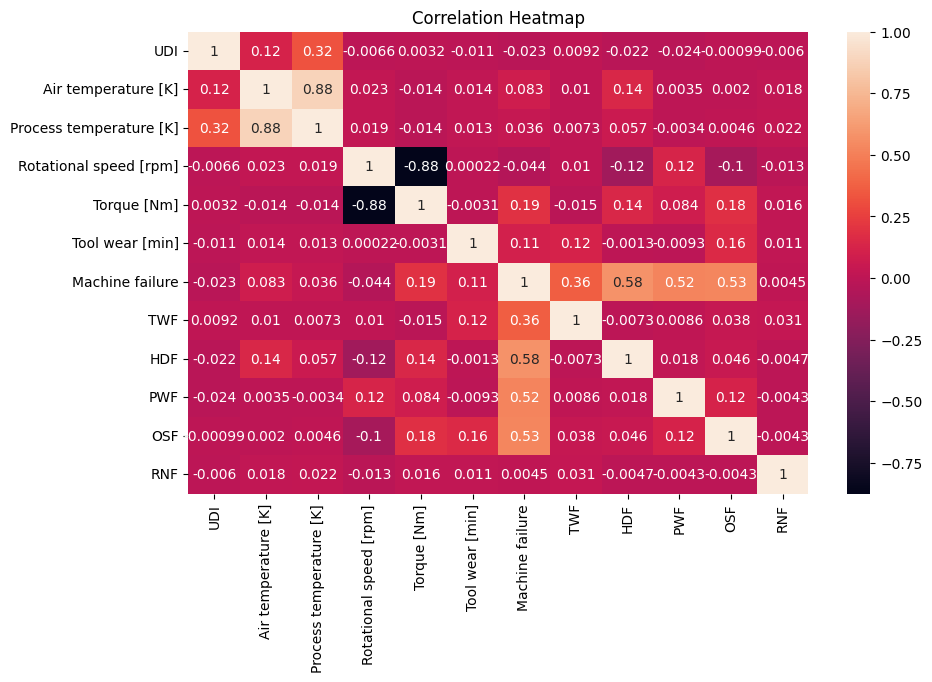

In [7]:
plt.figure(figsize=(10,6))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

In [8]:
X_simple = data[["Rotational speed [rpm]"]]

y_simple = data["Process temperature [K]"]

In [9]:
simple_model = LinearRegression()

simple_model.fit(X_simple, y_simple)

print("Simple Linear Regression Trained")

Simple Linear Regression Trained


In [10]:
y_pred_simple = simple_model.predict(X_simple)

In [11]:
mse_simple = mean_squared_error(
    y_simple,
    y_pred_simple
)

print("Simple Regression MSE:")

print(mse_simple)

Simple Regression MSE:
2.2004291212555707


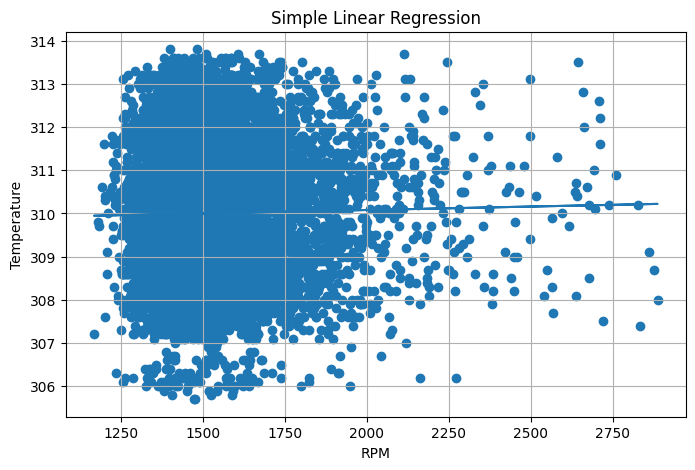

In [12]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_simple,
    y_simple
)

plt.plot(
    X_simple,
    y_pred_simple
)

plt.xlabel("RPM")

plt.ylabel("Temperature")

plt.title("Simple Linear Regression")

plt.grid(True)

plt.show()

In [13]:
X_multi = data[
    [
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]",
        "Air temperature [K]"
    ]
]

y_multi = data["Process temperature [K]"]

In [14]:
multi_model = LinearRegression()

multi_model.fit(
    X_multi,
    y_multi
)

print("Multiple Linear Regression Trained")

Multiple Linear Regression Trained


In [15]:
y_pred_multi = multi_model.predict(
    X_multi
)

In [16]:
mse_multi = mean_squared_error(
    y_multi,
    y_pred_multi
)

r2_multi = r2_score(
    y_multi,
    y_pred_multi
)

print("Multiple Regression MSE:")

print(mse_multi)

print("\nR2 Score:")

print(r2_multi)

Multiple Regression MSE:
0.5115862237963303

R2 Score:
0.7675925492612474


In [17]:
print("Simple Regression MSE:")

print(mse_simple)

print("\nMultiple Regression MSE:")

print(mse_multi)

Simple Regression MSE:
2.2004291212555707

Multiple Regression MSE:
0.5115862237963303


In [18]:
joblib.dump(
    multi_model,
    "factory_temperature_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [19]:
loaded_model = joblib.load(
    "factory_temperature_model.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [20]:
new_data = [[1500, 40, 20, 300]]

prediction = loaded_model.predict(
    new_data
)

print("Predicted Temperature:")

print(prediction[0])

Predicted Temperature:
310.0028123089754


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [21]:
encoded_data = pd.get_dummies(
    data,
    columns=["Type"],
    drop_first=True
)

print(encoded_data.head())

   UDI Product ID  Air temperature [K]  Process temperature [K]  \
0    1     M14860                298.1                    308.6   
1    2     L47181                298.2                    308.7   
2    3     L47182                298.1                    308.5   
3    4     L47183                298.2                    308.6   
4    5     L47184                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  Type_L  Type_M  
0    0    0    0    0   False    True  
1    0    0    0    0    True 

In [22]:
X = encoded_data[
    [
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]",
        "Type_L",
        "Type_M"
    ]
]

y = encoded_data["Machine failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

print(X_test.shape)

(8000, 7)
(2000, 7)


In [23]:
log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train,
    y_train
)

print("Logistic Regression Trained")

Logistic Regression Trained


In [24]:
y_pred = log_model.predict(X_test)

In [25]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:")

print(round(accuracy * 100, 2), "%")

Accuracy:
97.4 %


In [26]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[1930    9]
 [  43   18]]


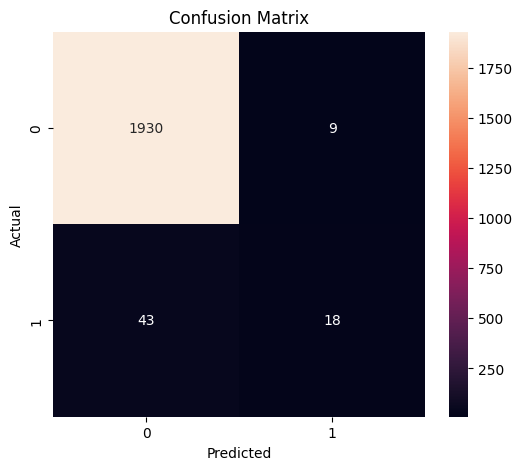

In [27]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()